In [1]:
import matplotlib.pyplot as plt
plt.style.use('default')

plt.rcParams['savefig.transparent'] = False
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Exploratory Data Analysis (EDA)

This section presents the exploratory data analysis conducted using multiple cleaned datasets. Since the required variables are distributed across different data sources, the analysis is performed separately on each dataset to examine customer demographics, purchasing behavior, product preferences, and churn patterns.

The objective is to gain an overall understanding of customer characteristics and validate data quality before clustering and predictive modeling in subsequent phases.

## Requirement
- Cleaned_Customers.csv
- Clean_Online_Sales_with_VIP.csv
- Cleaned_E_Commerce.csv

## Output
```
assets/images/
├── 01_gender_distribution.png
├── 02_region_distribution.png
├── 03_top_selling_categories.png
├── 04_revenue_distribution.png
└── 05_churn_distribution.png
```

In [2]:
import pandas as pd
import os

os.makedirs("../assets/images", exist_ok=True)

customers = pd.read_csv("../data/cleaned_data/Cleaned_CustomersData.csv")
sales = pd.read_csv("../data/processed/Online_Sales_with_VIP.csv")
ecommerce = pd.read_csv("../data/cleaned_data/Cleaned_E_Commerce_Dataset.csv")

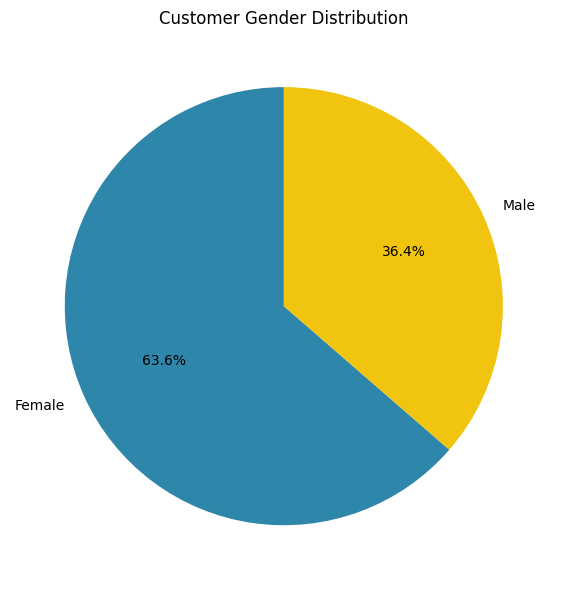

In [3]:
# plot gender distribution
gender_counts = customers['Gender'].value_counts().sort_index()
labels = ['Female', 'Male']
plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#2E86AB', '#F1C40F'])

plt.title("Customer Gender Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../assets/images/01_gender_distribution.png", dpi=300)
plt.show()

## Insight
The dataset is skewed toward female customers (63.6%), indicating a potential imbalance in customer representation.

This may influence downstream analysis, as patterns observed could be more reflective of female behavior than male customers.

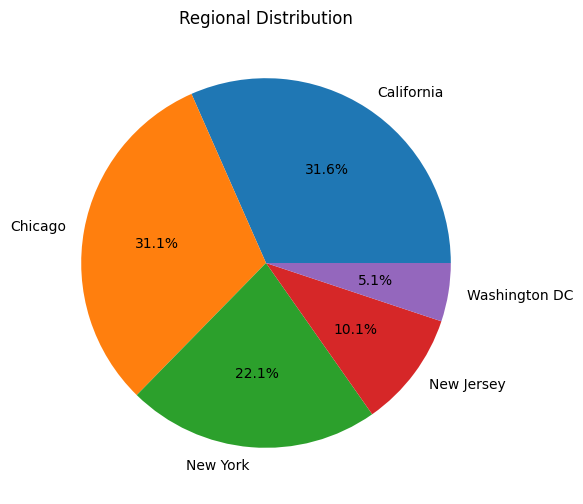

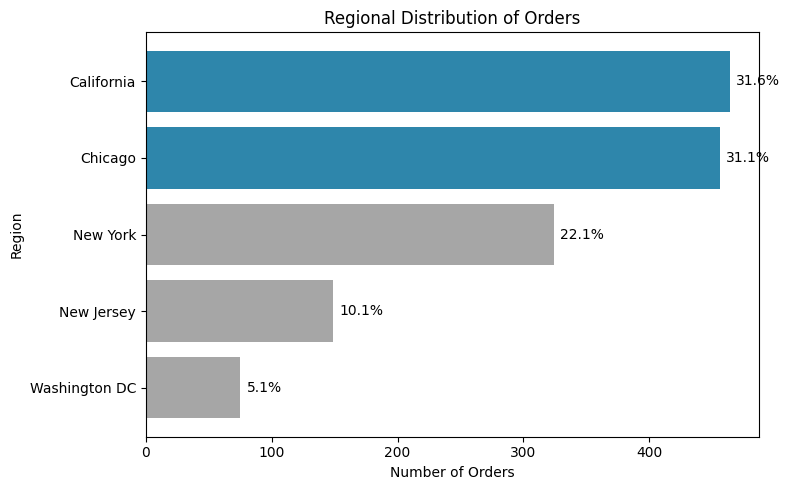

In [4]:
# plot location distribution
plt.figure(figsize=(8,6))
customers['Location'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Regional Distribution")
plt.ylabel("")
plt.savefig("../assets/images/02_region_distribution_pie_chart.png", dpi=300, bbox_inches='tight')
plt.show()

region_counts = customers['Location'].value_counts()

# percentage
region_pct = region_counts / region_counts.sum() * 100

# color top 2
colors = ['#2E86AB' if i < 2 else '#A6A6A6' for i in range(len(region_counts))]

plt.figure(figsize=(8,5))

bars = plt.barh(region_counts.index[::-1],
                region_counts.values[::-1],
                color=colors[::-1])

# add % labels
for i, (value, pct) in enumerate(zip(region_counts.values[::-1],
                                     region_pct.values[::-1])):
    plt.text(value + 5, i, f"{pct:.1f}%", va='center')

plt.title("Regional Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig("../assets/images/02_regional_distribution_bar_chart.png", dpi=300)
plt.show()

## Insight
Orders are highly concentrated in California and Chicago, which together account for the majority of total transactions.

New York forms a secondary tier, while New Jersey and Washington DC contribute relatively small shares.

This concentration suggests strong regional dependence, indicating that business performance is driven primarily by a few key markets.

There is an opportunity to expand growth in underperforming regions through targeted strategies.

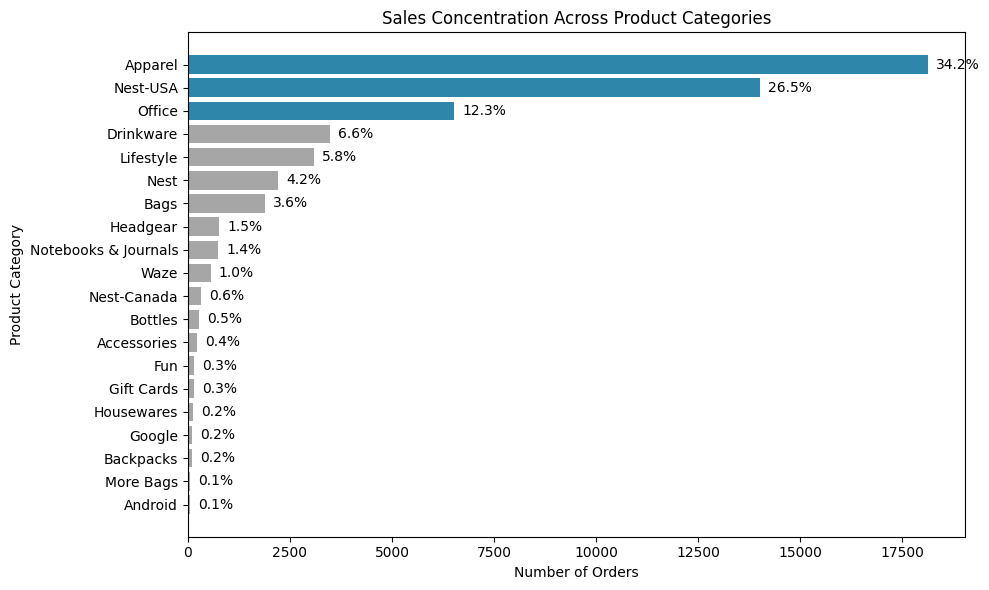

In [5]:
# plot product category frequency
import matplotlib.pyplot as plt

category_counts = sales['Product_Category'].value_counts()

# percentage
category_counts_pct = category_counts / category_counts.sum() * 100

# color top 3
colors = ['#2E86AB' if i < 3 else '#A6A6A6' for i in range(len(category_counts))]
plt.figure(figsize=(10,6))
bars = plt.barh(category_counts.index[::-1], category_counts.values[::-1], color=colors[::-1])

# add percentage labels
for i, (value, pct) in enumerate(zip(category_counts.values[::-1], category_counts_pct.values[::-1])):
    plt.text(value + 200, i, f"{pct:.1f}%", va='center')

plt.title("Sales Concentration Across Product Categories")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")

plt.tight_layout()
plt.savefig("../assets/images/03_selling_categories.png", dpi=300)
plt.show()

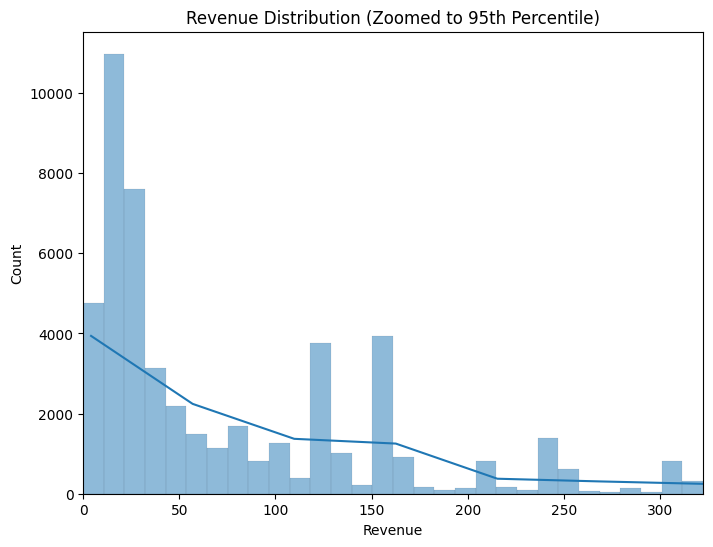

In [6]:
import seaborn as sns

# plot revenue histogram
upper = sales['Transaction_Value'].quantile(0.95)

plt.figure(figsize=(8,6))

sns.histplot(
    sales['Transaction_Value'],
    bins=30,
    binrange=(0,upper),
    kde=True
)

plt.xlim(0, upper)

plt.title("Revenue Distribution (Zoomed to 95th Percentile)")
plt.xlabel("Revenue")
plt.ylabel("Count")

plt.savefig("../assets/images/04_revenue_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## Insight
This pattern suggests that most customers make low-value purchases,
while a smaller group contributes disproportionately through higher spending.

This highlights an opportunity to identify and target high-value customers
for retention and personalized marketing strategies.

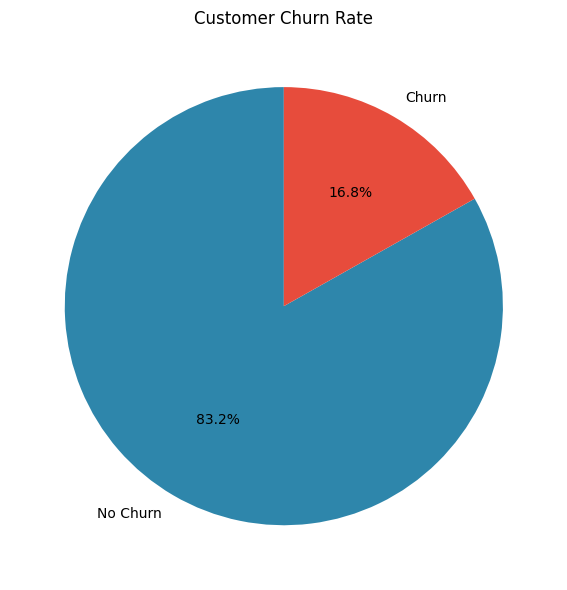

In [7]:
# plot churn distribution
churn_counts = ecommerce['Churn'].value_counts().sort_index()
labels = ['No Churn', 'Churn']
plt.figure(figsize=(6,6))
plt.pie(churn_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#2E86AB', '#E74C3C'])

plt.title("Customer Churn Rate")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../assets/images/05_churn_distribution.png", dpi=300)
plt.show()

## Insight
The churn rate is relatively low at 16.8%, indicating that the majority of customers remain active.

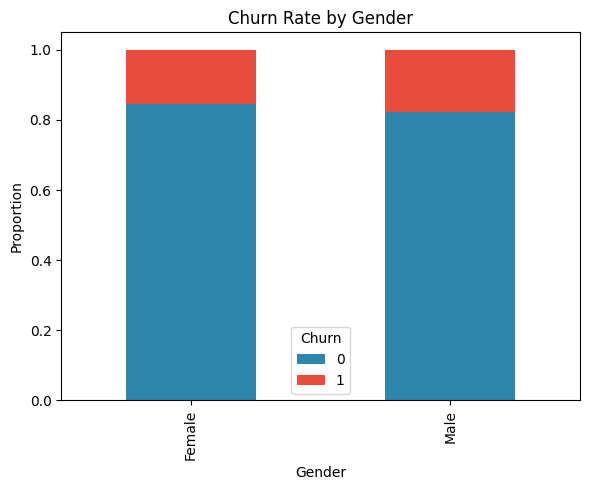

In [8]:
# Churn vs Gender

df = ecommerce.copy()
ct = pd.crosstab(df['Gender'], df['Churn'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(6,5), color=['#2E86AB', '#E74C3C'])

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")

plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("../assets/images/06_churn_vs_gender.png", dpi=300)
plt.show()

### Insight: Churn by Gender

Churn rates are similar for both genders, with males showing a slightly higher churn than females.

This suggests that gender is not a strong driver of churn, and other factors are likely more important.

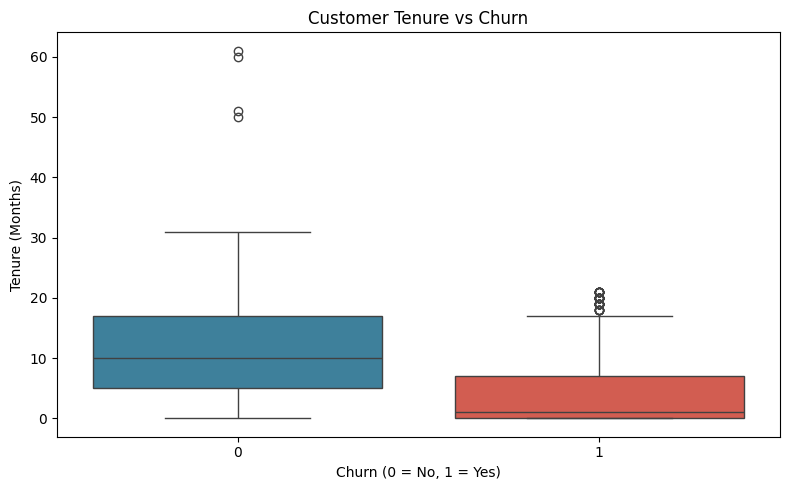

In [9]:
# Churn vs Tenure

df = ecommerce.copy()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Churn'], y=df['Tenure'], hue=df['Churn'], palette=['#2E86AB', '#E74C3C'], legend=False)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.savefig("../assets/images/07_churn_vs_tenure.png", dpi=300)
plt.show()

### Insight: Tenure vs Churn

Customers who churn tend to have significantly shorter tenure compared to those who stay.

This indicates that newer customers are more likely to churn, while long-term customers are more likely to remain loyal.